# Heterogeneous slope in Doubrava-Kozinec and its stability (SSR methods)


## Notes Before Running
- Activate local environment: `source setup/activate_optimized_octave.sh`
- Activate Jupyter venv: `source .venv/bin/activate`
- In Jupyter, select kernel **Octave (local-rsb)**


In [1]:
close all; clearvars; clc;
%plot -f png -r 600
pkg load sparsersb;

try
    graphics_toolkit('qt');
catch
    graphics_toolkit('gnuplot');
end
set(0, 'defaultfigurevisible', 'off');

fprintf('Working directory: %s\n', pwd);
fprintf('Graphics toolkit: %s\n', graphics_toolkit());



Working directory: /home/beremi/repos/slope_stability/slope_stability
Graphics toolkit: qt


## Heterogeneous slope in Doubrava-Kozinec and its stability (SSR methods)


=========================================================================

 This program solves a 2D slope stability problem by the modified shear
 strength reduction (SSR) method described in (Sysala et al., CAS 2025).
 The Mohr-Coulomb yield criterion, 3 Davis approaches (denoted by A, B, C),
 standard finite elements (P1, P2 or P4 elements) and meshes
 with different densities are considered. For P2 elements, the 7-point
 Gauss quadrature is used. To find the safety factor of the SSR method,
 two continuation techniques are available: direct and indirect. A case
 study on a heterogeneous river embankment with unconfined seepage from
 the locality Luzec (Czechia) is considered,
 see (Sysala et al., CAS 2023).

======================================================================



## The main input data


In [2]:
% elem_type - type of finite elements; available choices: 'P1', 'P2', 'P4'
elem_type='P2';

% Davis_type - choice of Davis' approach; available choices: 'A','B','C'
Davis_type='B';

% Mechanical parameters for each subdomain. In the following table, we
% specify in each column the following material parameters, respectively:
% [c0, phi, psi, young, poisson, gamma_sat, gamma_unsat], where
%    c0 ... Cohesion (c)
%    phi ... Friction angle (phi in degrees)
%    psi ... Dilatancy angle (psi in degrees)
%    young ... Young's modulus (E)
%    poisson ...  Poisson's ratio (nu)
%    gamma_sat ...   Specific weight - saturated (gamma_sat in kN/m^3)
%    gamma_unsat ... Specific weight - unsaturated (gamma_unsat in kN/m^3)
% If gamma_sat and gamma_unsat are not distinguished, use the same values
% for these parameters. Each row of the table represents one subdomain. If
% a homogeneous body is considered, only one row is prescribed.
mat_props = ...
    [14.0, 21.00, 0.00, 16000, 0.4, 21.0, 21.0;  % S1 - weathered claystone
    1.0, 33.00, 0.00, 16000, 0.4, 21.0, 19.0;  % S2 - fluvial gravel
    7.5, 30.25, 0.00, 16000, 0.4, 22.0, 21.0;  % S3 - fluvial clay
    1.6, 24.00, 0.00, 16000, 0.4, 21.0, 19.0;  % S4 - clayey sand
    2.0, 37.00, 0.00, 16000, 0.4, 21.0, 21.0;  % S5 - drainage
    1.6, 24.00, 0.00, 16000, 0.4, 21.0, 19.0;  % S6 - clayey sand
    50.0, 45.00, 0.00, 16000, 0.4, 19.0, 19.0;  % S7 - road
    1.6, 24.00, 0.00, 16000, 0.4, 21.0, 19.0]; % S8 - clayey sand

%  Hydraulic conductivity for each subdomain [m/day]
k = [0.864e-3  % S1 - weathered claystone
    86.4  % S2 - fluvial gravel
    0.864e-3  % S3 - fluvial clay
    0.86  % S4 - clayey sand
    86.4  % S5 - drainage
    0.86  % S6 - clayey sand
    0.864e-3  % S7 - road
    0.86]; % S8 - clayey sand


## Data from the reference element


In [3]:
% quadrature points and weights for volume integration
[Xi, WF] = ASSEMBLY.quadrature_volume_2D(elem_type);
% local basis functions and their derivatives
[HatP,DHatP1,DHatP2] = ASSEMBLY.local_basis_volume_2D(elem_type, Xi);


## Creation/loading of the finite element mesh


In [4]:
% Available Luzec mesh family in meshes/Luzec/ (nodes / elements):
%   P1:  4571 / 8772
%   P2: 17913 / 8772
[coord, elem, Q, material_identifier, surf] = MESH.load_mesh_Luzec(elem_type, 'meshes/Luzec/');

% Uncomment to reduce matrix bandwidth via Reverse Cuthill-McKee node reordering:
% [coord, elem, surf, Q] = MESH.reorder_mesh(coord, elem, surf, Q);

% number of nodes, elements and integration points + print
n_n=size(coord,2);
n_unknown=length(coord(Q)); % number of unknowns
n_e=size(elem,2);           % number of elements
n_q=length(WF);             % number of quadratic points
n_int = n_e*n_q ;           % total number of integrations points
%
fprintf('\n');
fprintf('Mesh data:');
fprintf('  number of nodes =%d ',n_n);
fprintf('  number of unknowns =%d ',n_unknown);
fprintf('  number of elements =%d ',n_e);
fprintf('  number of integration points =%d ',n_int);
fprintf('\n');



Mesh data:  number of nodes =17913   number of unknowns =35217   number of elements =8772   number of integration points =61404 


## Computation of porous water pressure


In [5]:
% Hydraulic conductivity ateach integration point
conduct0=SEEPAGE.heter_conduct(material_identifier,n_q,k);

% specific weight of water in kPa
grho=9.81;

% Dirichlet boundary conditions for pressure (problem dependent)
Q_D=(coord(2,surf(1,:))+coord(2,surf(2,:)))/2>=1e-1;
Q_w=true(1,n_n);
Q_w(unique(surf(:,Q_D)))=0;
% In case of the drain tile, the following condition is added:
Q_w((abs(coord(1,:)-93.07)<0.05)&(abs(coord(2,:)-18.16)<0.05))=0;

% Nonhomogeneous part of the pressure (problem dependent)
x1=91.12; y1=15.75;
x2=101.845; y2=22.40;
pw_D=zeros(1,n_n);
part1=(coord(1,:)<x1+1e-9)&(coord(2,:)<y1);
part2=(coord(1,:)>=x1+1e-9)&(coord(1,:)<x2+1e-9)&(coord(2,:)<((y2-y1)/(x2-x1))*(coord(1,:)-x1)+y1);
part3=(coord(1,:)>=x2+1e-9);
pw_D(part1)=grho*(y1-coord(2,part1));
pw_D(part2)=grho*(((y2-y1)/(x2-x1))*(coord(1,part2)-x1)+y1-coord(2,part2));
pw_D(part3)=grho*(y2-coord(2,part3));

% Computation on the pore pressure and its gradient
[pw, grad_p, mater_sat]=SEEPAGE.seepage_problem_2D...
    (coord,elem,Q_w,pw_D,grho,conduct0,HatP,DHatP1,DHatP2,WF);

% Saturation - a prescribed logical array indicating integration points
%              where the body is saturated. If gamma_sat and gamma_unsat
%              are the same, set saturation=true(1,n_int). Otherwise,
%              this logical array is derived from the phreatic surface.
mater_sat_ext=repmat(mater_sat,n_q,1);
saturation=mater_sat_ext(:);


seepage_newton summary: status=converged, it=9, rel_update=8.028697e-12, lin_it_total=329, wall_time=1.11 s


## Mechanical material Parameters at Integration Points


In [6]:
% Fields with prescribed material properties
fields = {'c0',      ... % Cohesion (c)
    'phi',     ... % Friction angle (phi in degrees)
    'psi',     ... % Dilatancy angle (psi in degrees)
    'young',   ... % Young's modulus (E)
    'poisson', ... % Poisson's ratio (nu)
    'gamma_sat', ... % Specific weight - saturated (gamma_sat in kN/m^3)
    'gamma_unsat'};  % Specific weight - unsaturated (gamma_unsat in kN/m^3)

% Convert properties to structured format.
materials = cellfun(@(x) cell2struct(num2cell(x), fields, 2), num2cell(mat_props, 2), 'UniformOutput', false);

% Material parameters at integration points.
[c0, phi, psi, shear, bulk, lame, gamma] = ...
    ASSEMBLY.heterogenous_materials(material_identifier, saturation, n_q, materials);


## Assembling for mechanics


In [7]:
% Assembling of the elastic stiffness matrix
[K_elast,B,WEIGHT,DPhi1_out,DPhi2_out]=ASSEMBLY.elastic_stiffness_matrix_2D(elem,coord,...
    DHatP1,DHatP2,WF,shear,lame);

% volume forces at integration points, size(f_V_int)=(2,n_int)
f_V_int = [-grad_p(1,:);-grad_p(2,:)-gamma] ;
% vector of volume forces
f_V=ASSEMBLY.vector_volume_2D(elem,coord,f_V_int,HatP,WEIGHT);


## Input parameters for the continuation methods


In [8]:
lambda_init = 0.7;              % Initial lower bound of lambda
d_lambda_init = 0.1;            % Initial increment of lambda
d_lambda_min = 1e-5;            % Minimal increment of lambda
d_lambda_diff_scaled_min = 0.001;% Minimal rate of increment of lambda
omega_max_stop = 7e7;           % Maximum omega, then stop
step_max = 100;                 % Maximum number of continuation steps


## Input parameters for Newton's solvers


In [9]:
it_newt_max = 50;               % Number of Newton's iterations
it_damp_max = 10;               % Number of iterations within line search
tol = 1e-4;                     % Relative tolerance for Newton's solvers
r_min = 1e-4;                   % Basic minimal regularization of the stiffness matrix


## Defining linear solver


In [10]:
% agmg folder is baked into LINEAR_SOLVERS.set_linear_solver
solver_type = 'DFGMRES_HYPRE_BOOMERAMG'; % Type of solver: "DIRECT", "DFGMRES_ICHOL", "DFGMRES_AGMG", "DFGMRES_HYPRE_BOOMERAMG"

linear_solver_tolerance = 1e-1;
linear_solver_maxit = 100;
deflation_basis_tolerance = 1e-3;
linear_solver_printing = 0;

% Optional BoomerAMG options (used when solver_type contains BOOMERAMG).
boomeramg_opts = struct('threads', 16, 'print_level', 0, ...
    'use_as_preconditioner', true);

[linear_system_solver] = LINEAR_SOLVERS.set_linear_solver(solver_type, ...
    linear_solver_tolerance, linear_solver_maxit, deflation_basis_tolerance, linear_solver_printing, Q, coord, boomeramg_opts);


## Constitutive problem and matrix builder


In [11]:
dim = 2;
n_strain = dim * (dim + 1) / 2;
constitutive_matrix_builder = CONSTITUTIVE_PROBLEM.CONSTITUTIVE(B, c0, phi, psi, Davis_type, shear, bulk, lame, WEIGHT, n_strain, n_int, dim);
% Enable element-level tangent assembly path for 2D B*D*B values.
constitutive_matrix_builder.set_element_data(elem, DPhi1_out, DPhi2_out);
disp(['2D element-level tangent mex enabled = ' , num2str(constitutive_matrix_builder.elem_use_mex)]);
disp(['2D constitutive mex enabled = ' , num2str(constitutive_matrix_builder.use_2D_mex)]);


%--------------------------------------------------------------------------


Element data set: n_p=6, n_e=8772, n_q=7, mex=1
2D element-level tangent mex enabled = 1
2D constitutive mex enabled = 1


## Profiler Setup


In [12]:
profiler = PROFILING.Profiler();
constitutive_matrix_builder.profiler = profiler;
linear_system_solver.profiler = profiler;


## Computation of the factor of safety for the SSR method


In [13]:
direct_on = 0; % Use direct continuation method.
indirect_on = 1; % Use indirect continuation method.

if direct_on  % Direct continuation method.
    fprintf('\n Direct continuation method\n');
    tic;
    [U2, lambda_hist2, omega_hist2, Umax_hist2] = CONTINUATION.SSR_direct_continuation(...
        lambda_init, d_lambda_init, d_lambda_min, d_lambda_diff_scaled_min, step_max, ...
        it_newt_max, it_damp_max, tol, r_min, K_elast, Q, f_V, ...
        constitutive_matrix_builder, linear_system_solver.copy());
    time_run = toc;
    fprintf("Running_time = %f \n", time_run);
end
if indirect_on     % Indirect continuation method.
    fprintf('\n Indirect continuation method\n');
    tic;
    [U3, lambda_hist3, omega_hist3, Umax_hist3] = CONTINUATION.SSR_indirect_continuation(...
        lambda_init, d_lambda_init, d_lambda_min, d_lambda_diff_scaled_min, step_max, ...
        omega_max_stop, it_newt_max, it_damp_max, tol, r_min, K_elast, Q, f_V, ...
        constitutive_matrix_builder, linear_system_solver.copy());
    time_run = toc;
    fprintf("Running_time = %f \n", time_run);
end

if ~isempty(strfind(upper(char(solver_type)), 'BOOMERAMG'))
    LINEAR_SOLVERS.hypre_boomeramg_clear();
end



 Indirect continuation method
Initialising K_r(Q,Q) sparse pattern ... done  (0.6 s, n_Q = 35217, nnz = 795565)
Building element scatter map ... done  (0.2 s, n_local_dof=12, map_size=10 MB)
Init step 1: lambda=0.7
newton summary: status=converged, it=6, rel_resid=1.585619e-05, lin_it_total=17, wall_time=0.28 s
   lambda_init = 0.7, d_lambda_init = 0.1, omega_init = 1505.431
Init step 2: searching lambda2 from lambda1=0.7
newton summary: status=converged, it=4, rel_resid=1.312079e-05, lin_it_total=10, wall_time=0.18 s
newton summary: status=converged, it=5, rel_resid=1.924769e-05, lin_it_total=15, wall_time=0.27 s
newton summary: status=converged, it=5, rel_resid=1.667171e-05, lin_it_total=17, wall_time=0.26 s
newton summary: status=converged, it=5, rel_resid=2.776100e-05, lin_it_total=21, wall_time=0.28 s
   lambda1 = 1, lambda2 = 1.1, d_lambda = 0.1, omega1 = 1505.4507, omega2 = 1505.4681, d_omega = 0.017434
Step 3: omega_target=1505.49, d_omega=0.0174336
newton_ind_SSR summary: sta

## Profiler Summary


In [14]:
if exist('profiler', 'var')
    profiler.print_summary();
end



  Profiler Summary
  Time      %       Calls  Operation
  --------- ------ ------  ------------------------------
     14.41s  63.5%    286  DFGMRES.solve
      2.62s  11.5%    517  CONSTITUTIVE.reduction
      1.64s   7.2%    132  DFGMRES.update_preconditioner
      1.14s   5.0%    584  CONSTITUTIVE.build_F
      0.99s   4.4%    413  CONSTITUTIVE.stress
      0.89s   3.9%    153  DFGMRES.A_orthogonalize
      0.45s   2.0%    171  CONSTITUTIVE.stress_tangent
      0.27s   1.2%     21  DFGMRES.setup_preconditioner
      0.19s   0.8%    153  CONSTITUTIVE.build_K_tangent_QQ_vals
      0.08s   0.4%    290  DFGMRES.expand_deflation_basis
  --------- ------ ------  ------------------------------
     22.68s                TOTAL

  Sub-profile: DFGMRES.solve  (14.41s total, 286 calls)
  --------- ------ ------  ------------------------------
      6.40s  44.4%    230  precond_apply
      2.76s  19.2%    230  arnoldi_ortho
      2.39s  16.6%    230  deflation_project
      1.22s   8.5%    286

## Unified Postprocessing via SolutionPlotter


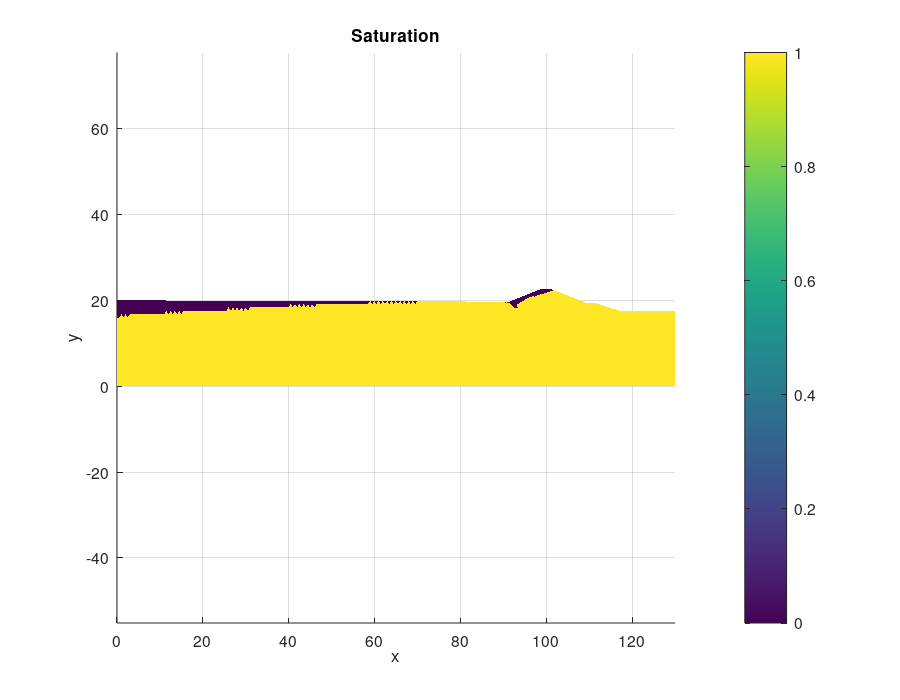

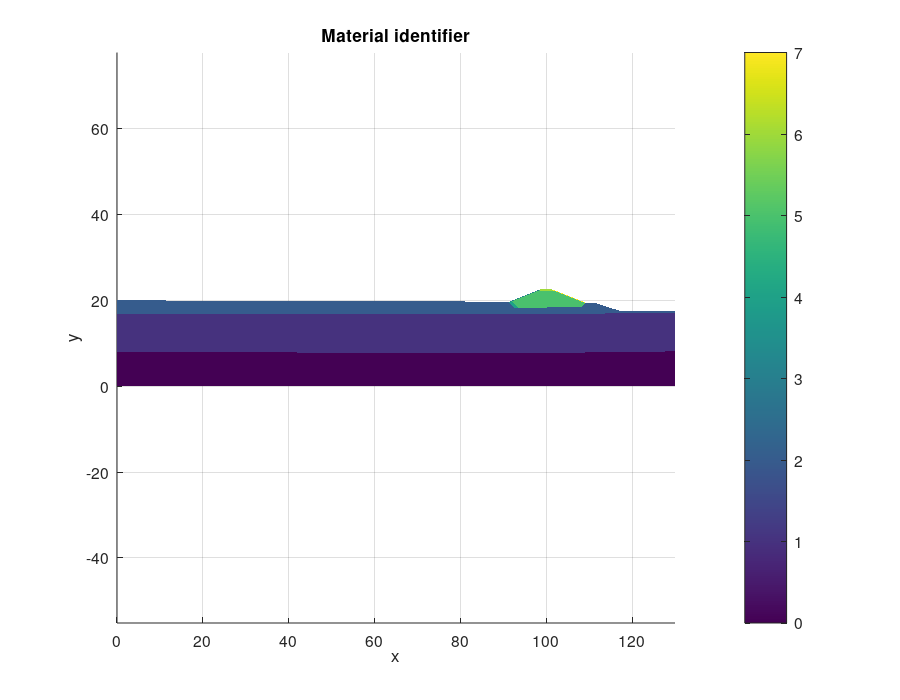

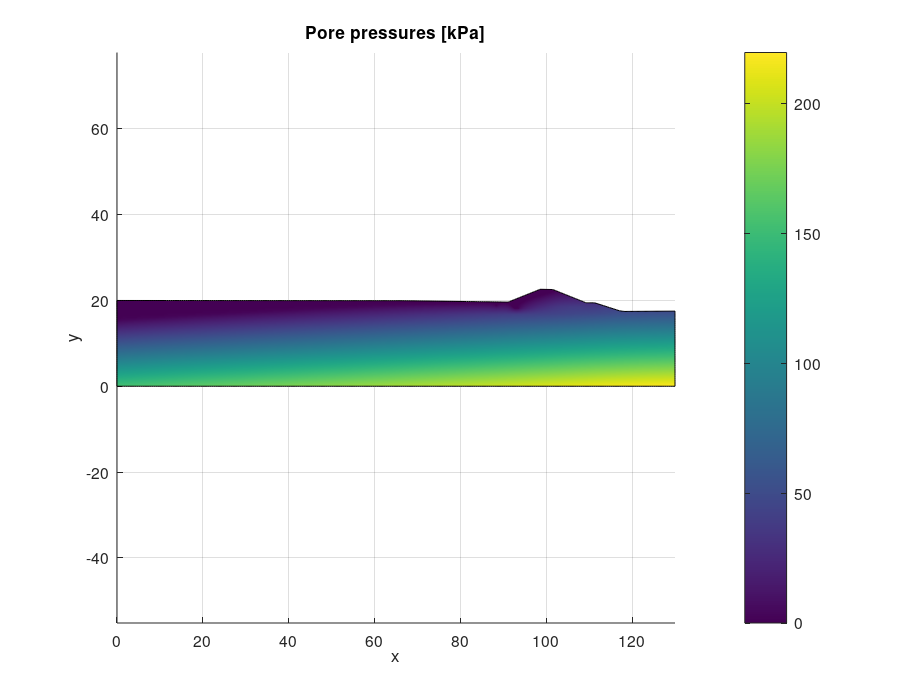

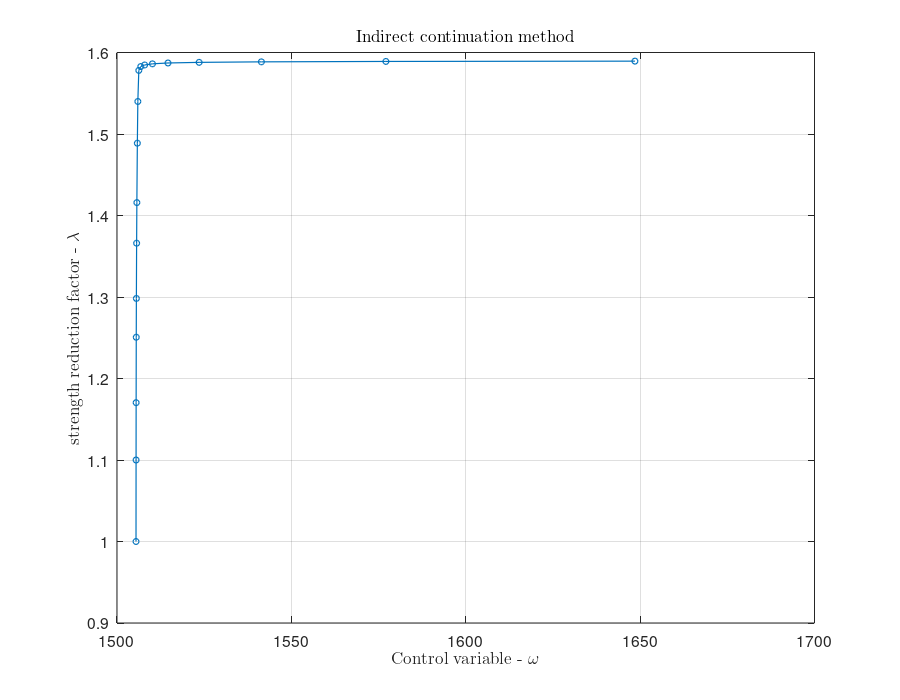

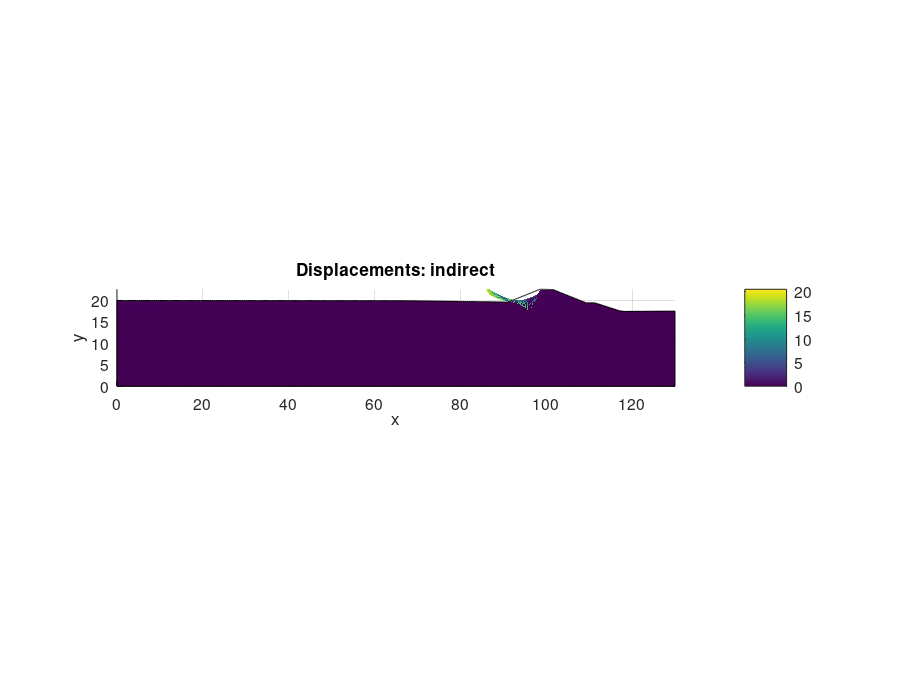

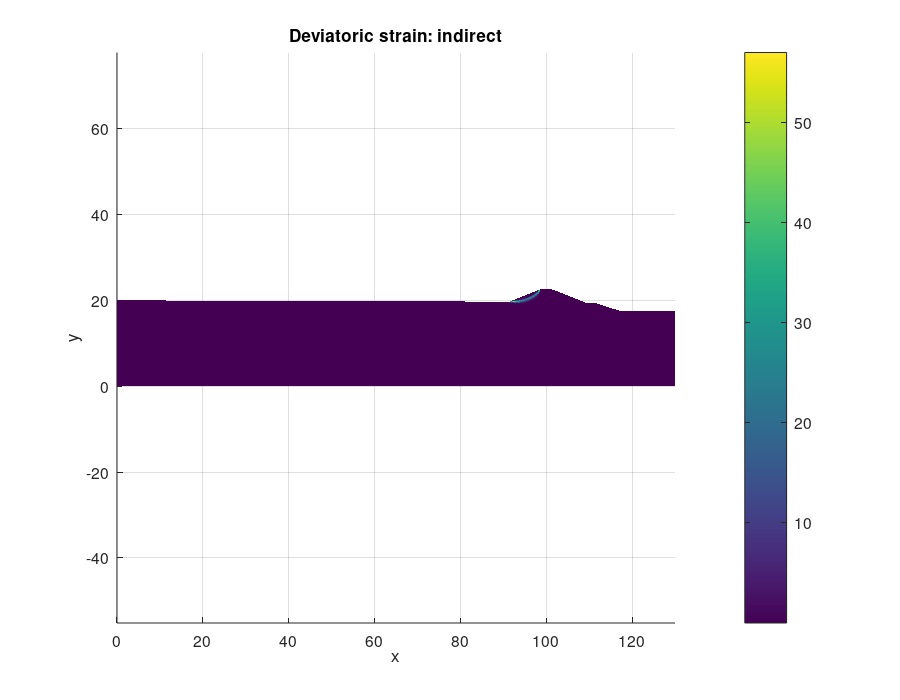

In [15]:
plotter = VIZ.SolutionPlotter(coord, elem, [], B, [], 'comsol');

if exist('material_identifier', 'var')
    plotter.set_material_identifier(material_identifier);
end
if exist('mater_sat', 'var')
    plotter.set_element_saturation(mater_sat);
end
if exist('pw', 'var')
    plotter.set_pore_pressure(pw);
end

if exist('U2', 'var') && exist('lambda_hist2', 'var') && exist('omega_hist2', 'var')
    if exist('Umax_hist2', 'var')
        Umax2 = Umax_hist2;
    else
        Umax2 = [];
    end
    plotter.add_solution('direct', U2, lambda_hist2, omega_hist2, Umax2, struct( ...
        'title', 'Direct continuation method', ...
        'xlabel', 'Control variable - $\omega$', ...
        'ylabel', 'strength reduction factor - $\lambda$', ...
        'marker', '-o'));
end

if exist('U3', 'var') && exist('lambda_hist3', 'var') && exist('omega_hist3', 'var')
    if exist('Umax_hist3', 'var')
        Umax3 = Umax_hist3;
    else
        Umax3 = [];
    end
    plotter.add_solution('indirect', U3, lambda_hist3, omega_hist3, Umax3, struct( ...
        'title', 'Indirect continuation method', ...
        'xlabel', 'Control variable - $\omega$', ...
        'ylabel', 'strength reduction factor - $\lambda$', ...
        'marker', '-o'));
end

if exist('U', 'var') && exist('t_hist', 'var') && exist('omega_hist', 'var')
    if exist('U_max_hist', 'var')
        UmaxLL = U_max_hist;
    else
        UmaxLL = [];
    end
    plotter.add_solution('indirect_LL', U, t_hist, omega_hist, UmaxLL, struct( ...
        'title', 'Indirect continuation method for the LL method', ...
        'xlabel', 'Control variable - $\omega$', ...
        'ylabel', 'Load factor - $t$', ...
        'marker', '-o'));
end

if plotter.n_solutions > 0
    plotter.plot_deviatoric_strain();
    plotter.plot_displacements();
    plotter.plot_convergence();
end

if exist('pw', 'var')
    plotter.plot_pore_pressure();
end
if exist('material_identifier', 'var')
    plotter.plot_material_map();
end
if exist('mater_sat', 'var')
    plotter.plot_saturation();
end
